# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: De Casa, Samantha Claire E.
- _Student No._: 2023-15141
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure
![Description](Absolute_Error.png)

The figure above is meant to compare the absolute error of the forward, backward, and central difference approximations when used to solve the first derivative of $f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$ given a 64-, 128-, and 256-point $h$ (also known as step size).

### Report discussion
It is evident from the figure that central and non-central difference approximations produce more consistent and accurate results when the step size $h$ is sufficiently small. In the plot, the step size $h$ ranges from $10^{-4}$ to $10^4$, and it is clear that eventually at larger values of $h$, the approximations are no longer approximating the derivative at $x = 0.004$.

Out of these two, however, central difference yields approximations with higher accuracy because it has a truncation error proportional to $h^2$, meaning its error decreases quadratically as $h$ shrinks. Non-central difference formulas (forward and backward), on the other hand, have a truncation error proportional to $h$, so their error srhinks linearly with the step size.

Looking outward, the appropriate method of differentiation depends on the available data and target accuracy. Since non-central difference formulas use the point on only one side of $x$, they are especially useful at boundaries where data exists on only one side. Forward difference is particularly helpful when the data at $x$ and points ahead of $x$ are available, while backward difference is more suitable when the data at $x$ and points behind $x$ are present. When the data on both sides are accessible, central difference is generally more accurate.


---
## Section 2: Code

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

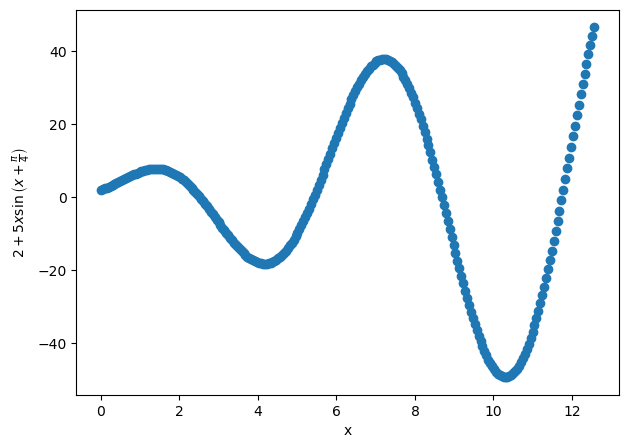

In [5]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)
x = np.linspace(0, 4*np.pi, 257)
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

In [20]:
def f(x): 
    return 2 + 5*x*np.sin(1*x+np.pi/4)

def F(x): #this is the first derivative of f(x)
    return 5*x*np.cos(1*x+np.pi/4) + 5*np.sin(1*x+np.pi/4) 

def forward_diff(g, x, dx): #forward difference formula
    return (g(x + dx) - g(x))/dx

def backward_diff(g, x, dx): #backward difference formula
    return (g(x) - g(x - dx))/dx

def central_diff(g, x, dx): #central difference formula
    return (g(x + dx) - g(x - dx))/(2*dx)

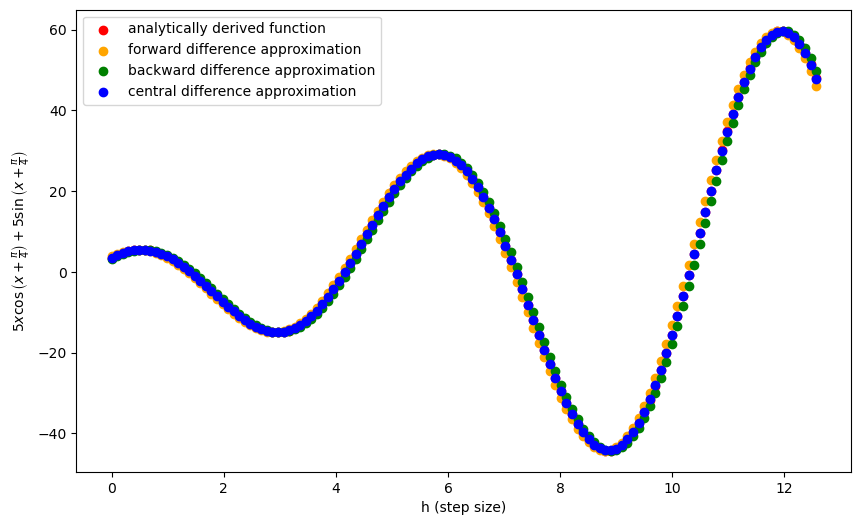

In [29]:
x = np.linspace(0, 4*np.pi, 128)
dx = 0.1 #step size

fig, ax = plt.subplots(figsize = (10, 6))

ax.scatter(x, F(x), color = "red", label = "analytically derived function")
ax.scatter(x, forward_diff(f, x, dx), color = "orange", label = "forward difference approximation")
ax.scatter(x, backward_diff(f, x, dx), color = "green", label = "backward difference approximation")
ax.scatter(x, central_diff(f, x, dx), color = "blue", label = "central difference approximation")

ax.set_xlabel("h (step size)")
ax.set_ylabel(r"$5x\cos\left(x + \frac{\pi}{4}\right) + 5\sin\left(x + \frac{\pi}{4}\right)$")
ax.legend()

fig.show()

In [40]:
'''this section is meant to compare the mean absolute error of each of the approximations to the analytically derived function if there are 64, 128, and 256 points. '''
x = 0.004

def dx(i): #this makes it easier to manipulate the desired number of step size
    return np.logspace(-4, 4, int(i))

def forward_err(dx): #error in forward difference approximation
    return [forward_diff(f, x, dxi) - F(x) for dxi in dx]

def backward_err(dx): #error in backward difference approximation
    return [backward_diff(f, x, dxi) - F(x) for dxi in dx]

def central_err(dx): #error in central difference approximation
    return [central_diff(f, x, dxi) - F(x) for dxi in dx]

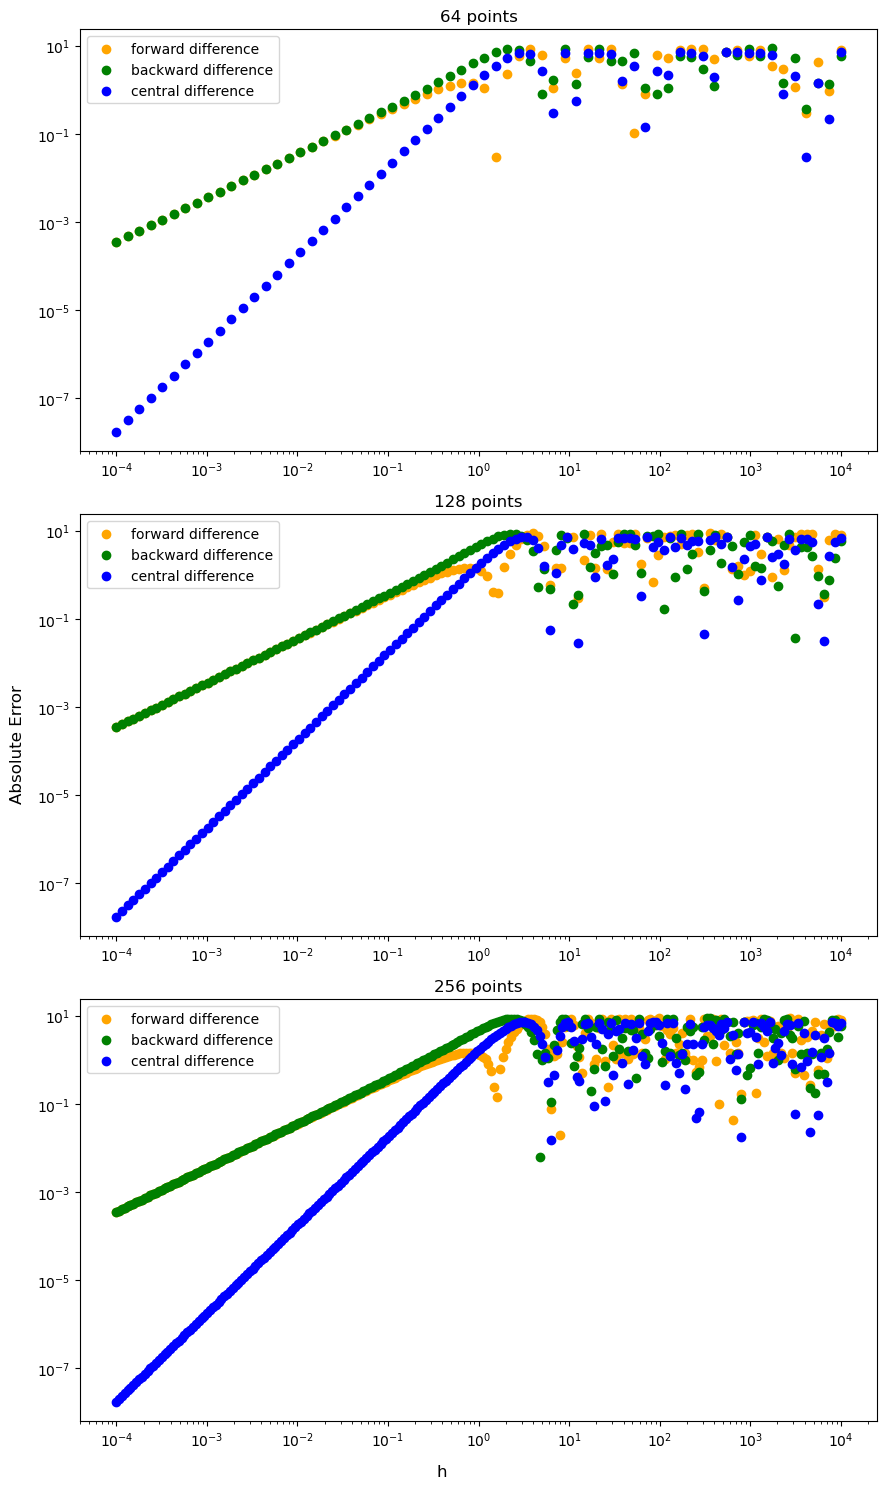

In [41]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (9, 15))
fig.supylabel("Absolute Error")
fig.supxlabel("h")

for ax in [ax1, ax2, ax3]:
    ax.set_yscale("log")
    ax.set_xscale("log")

ax1.scatter(dx(64), np.abs(forward_err(dx(64))), color = "orange", label = "forward difference")
ax1.scatter(dx(64), np.abs(backward_err(dx(64))), color = "green", label = "backward difference")
ax1.scatter(dx(64), np.abs(central_err(dx(64))), color = "blue", label = "central difference")
ax1.set_title("64 points")
ax1.legend()

ax2.scatter(dx(128), np.abs(forward_err(dx(128))), color = "orange", label = "forward difference")
ax2.scatter(dx(128), np.abs(backward_err(dx(128))), color = "green", label = "backward difference")
ax2.scatter(dx(128), np.abs(central_err(dx(128))), color = "blue", label = "central difference")
ax2.set_title("128 points")
ax2.legend()

ax3.scatter(dx(256), np.abs(forward_err(dx(256))), color = "orange", label = "forward difference")
ax3.scatter(dx(256), np.abs(backward_err(dx(256))), color = "green", label = "backward difference")
ax3.scatter(dx(256), np.abs(central_err(dx(256))), color = "blue", label = "central difference")
ax3.set_title("256 points")
ax3.legend()

plt.tight_layout()
fig.show()
fig.savefig('Absolute_Error.png')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


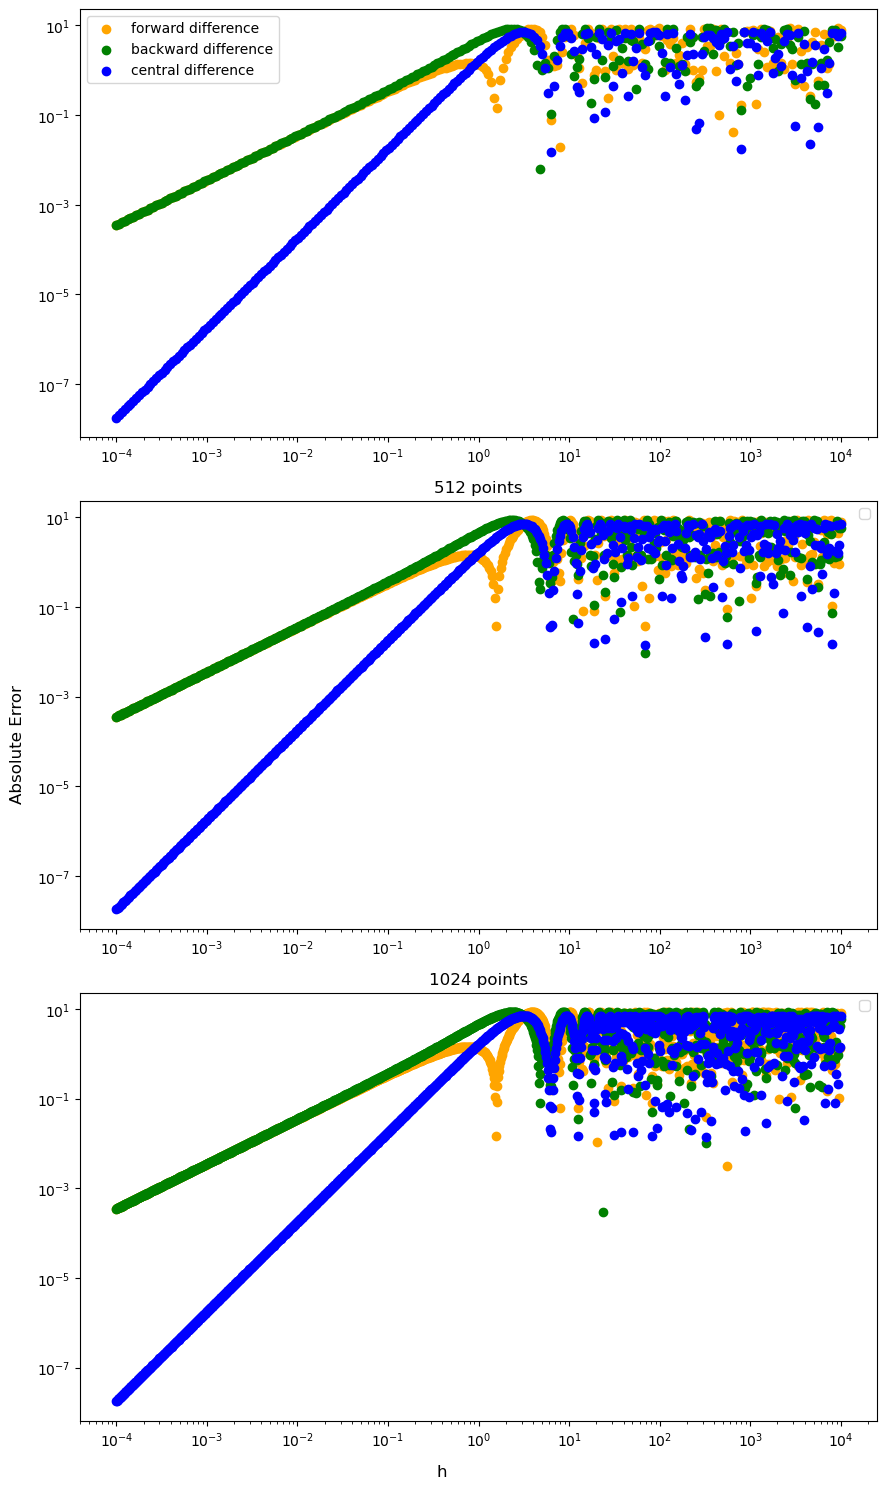

In [42]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (9, 15))
fig.supylabel("Absolute Error")
fig.supxlabel("h")

for ax in [ax1, ax2, ax3]:
    ax.set_yscale("log")
    ax.set_xscale("log")

ax1.scatter(dx(256), np.abs(forward_err(dx(256))), color = "orange", label = "forward difference")
ax1.scatter(dx(256), np.abs(backward_err(dx(256))), color = "green", label = "backward difference")
ax1.scatter(dx(256), np.abs(central_err(dx(256))), color = "blue", label = "central difference")
ax2.set_title("256 points")
ax1.legend()

ax2.scatter(dx(512), np.abs(forward_err(dx(512))), color = "orange")
ax2.scatter(dx(512), np.abs(backward_err(dx(512))), color = "green")
ax2.scatter(dx(512), np.abs(central_err(dx(512))), color = "blue")
ax2.set_title("512 points")
ax2.legend()

ax3.scatter(dx(1024), np.abs(forward_err(dx(1024))), color = "orange")
ax3.scatter(dx(1024), np.abs(backward_err(dx(1024))), color = "green")
ax3.scatter(dx(1024), np.abs(central_err(dx(1024))), color = "blue")
ax3.set_title("1024 points")
ax3.legend()

plt.tight_layout()
fig.show()

#### Problem 1 code summary

The purpose of this algorithm is to compare the absolute error of each of the approximations to the analytically derived function if there are 64, 128, 256, 512, and 1024 step points. Since the exercise involves plotting the absolute error versus step size for varying step sizes, I defined a step size function `dx(i)` which creates the target number of step points from $10^{-4}$ to $10^{4}$ so that I can simply call the `forward_err()`, `backward_err()`, and `central_err()` function (whose purpose is to return the error) over and over again for plotting.

---

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [12]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]
